# Tutorial 1 - Indicators of Hydrologic Alteration (IHA)

This tutorial demonstrates how to use the `SARAwater` package to compute the Indicators of Hydrologic Alteration (IHA) for a river reach. The IHA metrics help assess the impact of flow alterations on aquatic ecosystems.

## Import libraries

In [70]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sarawater as sara

## Set plot style

Import `matplotlib`'s custom settings from the external file `stylesheet.mplstyle` to set the style of the plots.

In [71]:
plt.style.use("stylesheet.mplstyle")

Set color array for the scenarios. The first element of this list will be the color of the first scenario added to the Reach, and so on with the following scenarios.

In [72]:
scenario_colors = ["tab:red", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink"]

## Define paths for two input files: flow time series and Minimum Flow Requirements

First, let's define the paths to the two input files we will import:
-  the input CSV file containing the flow discharge time series for the reach; the CSV file should have at least two columns: "Date" and "Q", where "Date" contains the timestamps and "Q" contains the flow discharge values in cubic meters per second (m³/s).
- the Minimum vital Flow Requirements for the reach, with fixed monthly requirements (MFR); the CSV file has two columns: the first column is the month of the year, the second column contains the fixed monthly requirement in l/s.

In [73]:
input_csv_filepath = os.path.join("data", "daily_discharge_7y.csv")
min_release_filepath = os.path.join("data", "minimum_flow_requirements.csv")

## Read the discharge data and create a reach object

### Read the CSV data

In [74]:
# Read CSV with automatic date parsing
reach_df = pd.read_csv(input_csv_filepath, parse_dates=["Date"])

# Convert to list of datetime objects
datetime_list = reach_df["Date"].dt.to_pydatetime().tolist()

# Put the discharge data into a numpy array
discharge_data = np.array(reach_df["Q"].to_list())

### Initialize a reach object

In [75]:
Qabs_max = 3
my_reach = sara.Reach("My Reach", datetime_list, discharge_data, Qabs_max)

## Add scenarios to the reach object

### Minimum Flow Requirement (MFR) scenario

In [76]:
# Read the minimum release values from CSV
minrel_df = pd.read_csv(min_release_filepath, header=None)

# Get the minimum release values (second column), convert l/s to m3/s
Qreq_months = np.array(minrel_df[1].tolist()) / 1000.0

# Create a constant scenario with these values
MFR_scenario = sara.ConstScenario(
    name="MFR",
    description="Minimum Flow Requirement scenario from CSV file",
    reach=my_reach,
    Qreq_months=Qreq_months,
)

# Add the scenario to the reach
my_reach.add_scenario(MFR_scenario)

### Ecological scenario (using the built-in method)

In [77]:
my_reach.add_ecological_flow_scenario(
    "DE", "Ecological Flow Scenario with default parameters"
)

Scenario(name=DE, description=Ecological Flow Scenario with default parameters, reach=My Reach)

### Proportional release scenario (using the built-in method)

In [78]:
prop_scenario = sara.PropScenario(
    name="Prop_06_30",
    description="Proportional scenario",
    reach=my_reach,
    Qbase=0.6 * np.min(Qreq_months),
    c_Qin=0.3,
    Qreq_min=np.min(Qreq_months),
    Qreq_max=np.max(my_reach.scenarios[1].Qreq_months),
)
my_reach.add_scenario(prop_scenario)

### Let's check we added the scenarios correctly

In [79]:
my_reach.print_scenarios()

scenarios[0]: MFR | Minimum Flow Requirement scenario from CSV file
scenarios[1]: DE | Ecological Flow Scenario with default parameters
scenarios[2]: Prop_06_30 | Proportional scenario


## How to delete existing scenarios

To delete a scenario, you can run `my_reach.scenarios.pop(N)`, where the number `N` in the parenthesis is the index of the list `scenarios` corresponding to the scenario you want to remove.

In [80]:
# my_reach.scenarios.pop(2) # This deletes the Proportional Scenario

## Compute the released flow discharge for each scenario and compute the IHA indices (IARI and normalized IHA)

In [81]:
for scenario in my_reach.scenarios:
    scenario.compute_Qrel()
    scenario.compute_IHA_index(index_metric="IARI")
    scenario.compute_IHA_index(index_metric="normalized_IHA")
    scenario.compute_natural_abstracted_volumes()

Let's take a look at the computed IHA values for a given scenario...

In [82]:
scenario_to_look_at = my_reach.scenarios[0]

In [83]:
scenario_to_look_at.IHA.keys()

dict_keys(['Group1', 'Group2', 'Group3', 'Group4', 'Group5'])

In [84]:
scenario_to_look_at.IHA["Group1"].keys()

dict_keys(['mean_january', 'mean_february', 'mean_march', 'mean_april', 'mean_may', 'mean_june', 'mean_july', 'mean_august', 'mean_september', 'mean_october', 'mean_november', 'mean_december'])

In [85]:
scenario_to_look_at.IHA["Group1"]["mean_january"]

array([0.076     , 0.076     , 0.076     , 0.07875006, 0.076     ,
       0.06835642, 0.06221929, 0.08966368])

...and at the corresponding values of the IARI index, which is also computed for each year and for each group of IHA indices.

In [86]:
scenario_to_look_at.IARI.aggregated

array([0.91751812, 0.70556946, 0.82670574, 2.19080349, 2.93206332,
       0.76951697, 0.57094374, 2.10835473])

In [87]:
scenario_to_look_at.IARI.groups

{'Group1': array([0.21808736, 0.25226811, 0.19930973, 0.22561403, 0.25074644,
        0.28030796, 0.41807374, 0.25895199]),
 'Group2': array([0.20250532, 0.26746002, 0.14654441, 0.25013714, 0.36920102,
        0.47257551, 0.69920319, 0.34774854]),
 'Group3': array([1.61987041e-03, 0.00000000e+00, 0.00000000e+00, 2.57446809e+00,
        7.97872340e-01, 0.00000000e+00, 1.38297872e-01, 2.72511603e+00]),
 'Group4': array([ 2.41052632,  1.20388471,  2.08220551,  5.75388471, 11.2160401 ,
         1.33984962,  0.86842105,  4.9612782 ]),
 'Group5': array([1.75485175, 1.80423446, 1.70546903, 2.14991347, 2.02645668,
        1.75485175, 0.73072286, 2.24867891])}

In [88]:
scenario_to_look_at.IARI.groups["Group1"]

array([0.21808736, 0.25226811, 0.19930973, 0.22561403, 0.25074644,
       0.28030796, 0.41807374, 0.25895199])

## Analyse the results using a ReachPlotter object

### Initialize the plotter

In [92]:
plotter = sara.ReachPlotter(my_reach, scenario_colors=scenario_colors)

### Plot samples of released flow discharge

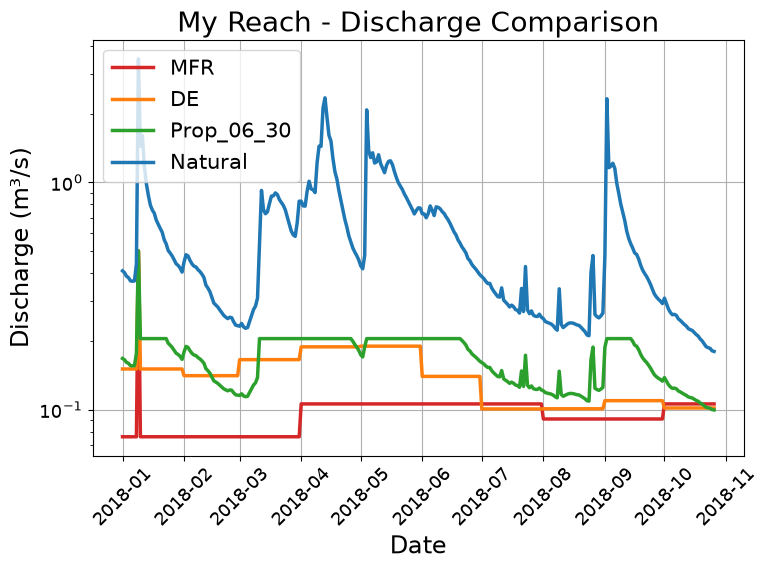

In [93]:
year = 2018
start_date = f"{year}-01-01"
end_date = f"{year}-12-31"
plotter.plot_scenarios_discharge(start_date=start_date, end_date=end_date)
plt.xticks(rotation=45)
plt.tight_layout()

### IHA and IARI plots

<Axes: title={'center': 'My Reach - IARI vs Abstracted Volume'}, xlabel='Ecohydrological quality $(1 - IARI)$ [-]', ylabel='Normalized abstracted volume $V_{der}/V_{nat}$ [-]'>

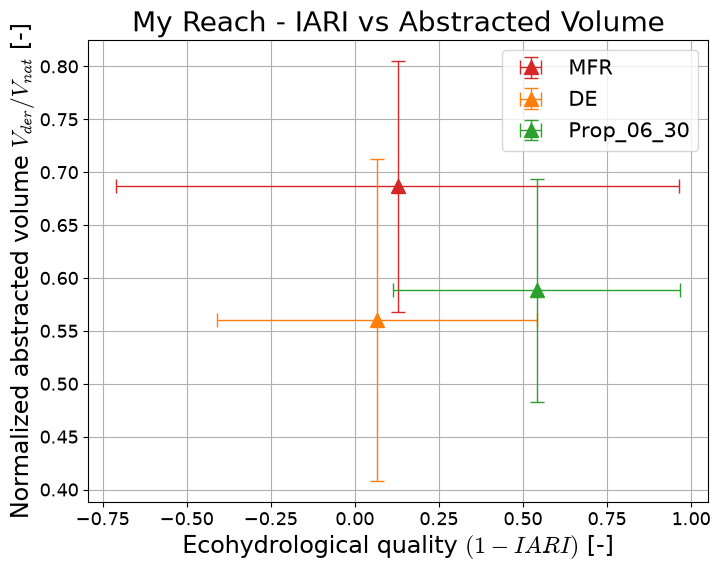

In [94]:
# plotter.plot_iha_parameters()
# plotter.plot_iha_boxplots()
# plotter.plot_iari_groups()
# plotter.plot_iari_summary()
# plotter.plot_cases_duration()
# plotter.plot_monthly_abstraction()
# plotter.plot_nIHA_summary()
# plotter.plot_nIHA_vs_volume()
plotter.plot_iari_vs_volume(save=True)